In [28]:
import scipy
import numpy as np
import pandas as pd

from datasets import load_dataset

from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import LabelEncoder

import os
from pprint import pprint
from time import perf_counter as pf
from tqdm import tqdm

import torch
from torch.nn import functional as F

In [3]:
ds = load_dataset('tattabio/ec_classification')
train = ds['train']
test = ds['test']

In [4]:
def find_file(dir, uniprot_id):
    filenames = os.listdir(dir)
    for fname in filenames:
        if uniprot_id in fname:
            return pd.read_csv(os.path.join(dir, fname))
    
    return None

find_file('data/ec_classification/secondary_centroids', 'Q59478')

,id,conf_type_id,beg_chain,beg_seq,beg_res,end_chain,end_seq,end_res,n_atoms,mean_x,mean_y,mean_z
0,HELX_LH_PP_P1,HELX_LH_PP_P,A,20,ALA,A,23,PRO,24,9.164,-17.119,11.241
1,HELX_RH_3T_P1,HELX_RH_3T_P,A,25,PRO,A,27,ASP,19,5.554,-13.986,2.829
2,TURN_TY1_P1,TURN_TY1_P,A,28,LYS,A,28,LYS,9,0.880,-17.277,1.432
3,BEND1,BEND,A,29,PHE,A,29,PHE,11,0.575,-13.000,-0.315
4,TURN_TY1_P2,TURN_TY1_P,A,32,SER,A,33,GLY,10,6.820,-8.430,-7.573
...,...,...,...,...,...,...,...,...,...,...,...,...
73,BEND24,BEND,A,284,LYS,A,286,GLY,20,-4.099,15.037,12.145
74,TURN_TY1_P23,TURN_TY1_P,A,288,PRO,A,289,ASP,15,-0.282,8.212,18.534
75,STRN22,STRN,A,291,TYR,A,302,THR,103,-5.322,-6.414,1.897
76,BEND25,BEND,A,304,GLY,A,304,GLY,4,-4.763,-6.814,-20.690


In [5]:
train_secondary_centroids = {}
test_secondary_centroids = {}
for row in tqdm(train):
    maybe_csv = find_file('data//ec_classification//secondary_centroids//', row['Entry'])
    
    if maybe_csv is not None:
        train_secondary_centroids[row['Entry']] = maybe_csv

for row in tqdm(test):
    maybe_csv = find_file('data//ec_classification//secondary_centroids//', row['Entry'])
    
    if maybe_csv is not None:
        test_secondary_centroids[row['Entry']] = maybe_csv
    

100%|██████████| 128/128 [00:01<00:00, 104.98it/s]


In [6]:
train_secondary_centroids.keys()

dict_keys(['Q9LQC0', 'A0AFT8', 'P74133', 'O31534', 'P34697', 'P19666', 'P80734', 'Q54RN1', 'Q8U1L4', 'P9WMK7', 'P22759', 'D0LZ73', 'Q9CBQ2', 'Q9KFH7', 'Q8PU61', 'F1SVE4', 'F1SVL1', 'F1SVE1', 'Q12284', 'Q8JGM4', 'Q54HS3', 'P97443', 'Q84WW6', 'Q75D88', 'Q55AX2', 'Q6C4Y5', 'Q6AW06', 'Q8TEK3', 'B1Q3J6', 'Q9M548', 'P25265', 'O31504', 'P25201', 'Q9KVZ8', 'Q58724', 'Q8PW90', 'A5W820', 'B0RTZ8', 'Q3SKJ2', 'Q8TU04', 'O32865', 'P80187', 'Q8TU05', 'P49158', 'Q97DB1', 'A5WDG8', 'B1VKF0', 'Q6UX98', 'Q4I1J3', 'Q76IC6', 'Q59NR8', 'Q9WZ43', 'Q7U5S4', 'O24982', 'A0QZ13', 'Q9UKN8', 'Q9SGH2', 'Q9M8T9', 'Q8WYB5', 'Q06508', 'Q41745', 'Q11087', 'Q59601', 'Q54XS6', 'Q93571', 'F4HPP7', 'Q9VR91', 'Q3U487', 'Q3T1H6', 'O15541', 'O00237', 'P43254', 'Q96G75', 'Q8IPJ3', 'Q1L8G6', 'P50636', 'Q9BYM8', 'Q9VF81', 'Q06644', 'Q9NX78', 'P9WN05', 'P46961', 'P53306', 'O64761', 'Q04082', 'A0QLI5', 'Q9I788', 'A8GG78', 'A3UNN4', 'Q04806', 'A0A1W2PR19', 'P0CG30', 'P26697', 'O31502', 'Q09103', 'P0ABN1', 'Q9C5E5', 'O52951', 'O967

In [ ]:
# train_secondary_centroids['Q54RN1']

,id,conf_type_id,beg_chain,beg_seq,beg_res,end_chain,end_seq,end_res,n_atoms,mean_x,mean_y,mean_z
0,HELX_RH_AL_P1,HELX_RH_AL_P,A,2,ASN,A,14,ALA,97,-22.439,37.128,-22.035
1,BEND1,BEND,A,15,ILE,A,15,ILE,8,-18.149,27.330,-19.051
2,STRN1,STRN,A,22,TYR,A,22,TYR,12,-3.087,15.245,-9.534
3,STRN2,STRN,A,24,TYR,A,28,LYS,43,6.011,8.958,-2.807
4,TURN_TY1_P1,TURN_TY1_P,A,29,PHE,A,30,GLY,15,13.583,3.608,0.680
...,...,...,...,...,...,...,...,...,...,...,...,...
97,STRN31,STRN,A,383,SER,A,383,SER,6,-12.943,-23.072,18.307
98,BEND33,BEND,A,384,THR,A,385,ILE,15,-15.120,-25.381,16.115
99,HELX_LH_PP_P6,HELX_LH_PP_P,A,386,GLU,A,390,THR,36,-17.999,-32.637,22.268
100,HELX_LH_PP_P7,HELX_LH_PP_P,A,395,PRO,A,398,THR,28,-34.906,-43.095,28.618


In [37]:
serieses = []
for key in train_secondary_centroids.keys():
    serieses.append(train_secondary_centroids[key].conf_type_id)

for key in test_secondary_centroids.keys():
    s = train_secondary_centroids.get(key)
    if s is not None:
        serieses.append(s)

In [38]:
pd.concat(serieses).unique()

<ArrowStringArray>
['HELX_LH_PP_P',   'TURN_TY1_P', 'HELX_RH_3T_P', 'HELX_RH_AL_P',
         'BEND', 'HELX_RH_PI_P',         'STRN']
Length: 7, dtype: str

In [19]:
# secondary = train_secondary_centroids['P22759']
secondary = train_secondary_centroids['Q54RN1']

In [20]:
distances = euclidean_distances(secondary[['mean_x', 'mean_y', 'mean_z']])

In [21]:
encoded_conf_type = LabelEncoder().fit_transform(secondary.conf_type_id)

In [ ]:
LabelEncoder().fit_transform(pd.concat(serieses).unique())

array([1, 6, 2, 3, 0, 4, 5])

In [22]:
c1 = np.repeat(np.array(encoded_conf_type)[:, np.newaxis], repeats=len(encoded_conf_type), axis=1)

In [23]:
secondary.conf_type_id

0      HELX_RH_AL_P
1              BEND
2              STRN
3              STRN
4        TURN_TY1_P
           ...     
97             STRN
98             BEND
99     HELX_LH_PP_P
100    HELX_LH_PP_P
101            BEND
Name: conf_type_id, Length: 102, dtype: str

In [41]:
c2 = c1.T

In [42]:
c2

array([[3, 0, 4, ..., 1, 1, 0],
       [3, 0, 4, ..., 1, 1, 0],
       [3, 0, 4, ..., 1, 1, 0],
       ...,
       [3, 0, 4, ..., 1, 1, 0],
       [3, 0, 4, ..., 1, 1, 0],
       [3, 0, 4, ..., 1, 1, 0]], shape=(102, 102))

In [43]:
dist_and_type = np.stack([distances/np.max(distances), c1/np.max(c1), c2/np.max(c2)])

In [44]:
from matplotlib import pyplot as plt

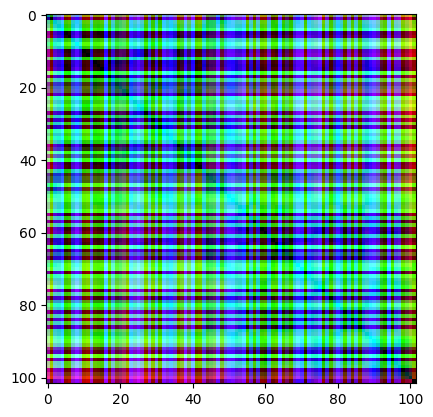

In [45]:
plt.imshow(np.transpose(dist_and_type, (1, 2, 0)))

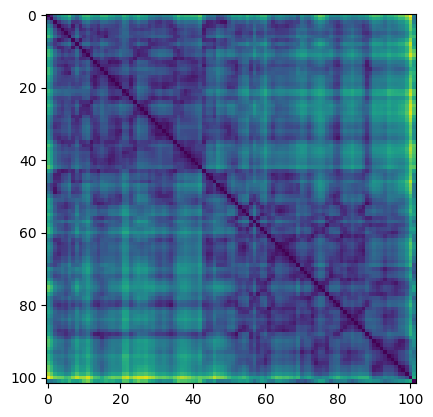

In [46]:
plt.imshow(distances)